<a href="https://colab.research.google.com/github/Swastika-Roy/Python-concepts/blob/main/HandlingInconsistentData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import pandas as pd

#load data
df = pd.read_csv('/content/03_inconsistent_data.csv')
print('Org data shape : ',df.shape)
print("\nFirst few rows:")
df

Org data shape :  (20, 10)

First few rows:


,Customer_ID,Name,Address,Phone,Email,Birth_Date,Country,State,Annual_Income,Active_Status
0,C001,John Smith,123 Main St,555-0101,john@email.com,1990-01-15,USA,NY,"$50,000",Yes
1,C002,SARAH JOHNSON,456 Oak Ave,(555) 0102,SARAH@EMAIL.COM,02/20/1985,usa,New York,60000,yes
2,C003,mike williams,789 Pine Rd,555.0103,mike@Email.Com,1992-03-10,United States,ny,"$75,000.00",Y
3,C004,Emma Brown,321 Elm St,5550104,emma@email.com,04/05/1988,US,CA,45000,TRUE
4,C005,DAVID JONES,654 Maple Dr,+1-555-0105,DAVID@EMAIL.COM,1995-06-22,U.S.A.,California,"$82,500",True
5,C006,lisa garcia,987 Cedar Ln,555-0106,lisa@Email.Com,07/30/1983,USA,ca,55000,true
6,C007,Robert Miller,147 Birch Way,(555) 0107,robert@email.com,1991-08-14,United States,TX,"$68,000.00",1
7,C008,JENNIFER DAVIS,258 Oak St,555.0108,JENNIFER@EMAIL.COM,09/12/1987,us,Texas,72000,No
8,C009,william rodriguez,369 Pine Ave,5550109,william@Email.Com,1993-10-25,U.S.A.,tx,"$91,000",no
9,C010,Mary Martinez,741 Elm Dr,+1-555-0110,mary@email.com,11/18/1989,USA,FL,63000,N


problems -

In [3]:
#PHONE FORMAT PATTERNS
phone_patterns = df['Phone'].apply(lambda x : re.sub(r'\\d','X',str(x))).value_counts()
phone_patterns

,count
Phone,
555-0101,1
(555) 0102,1
555.0103,1
5550104,1
+1-555-0105,1
555-0106,1
(555) 0107,1
555.0108,1
5550109,1


In [5]:
#Email case patterns
email_patterns = df['Email'].apply(lambda x : "UPPER" if x.isupper() else ("lower" if x.islower() else "mixed") ).value_counts()
email_patterns

,count
Email,
lower,8
UPPER,6
mixed,6


In [21]:
#date format patterns

date_patterns = df['Birth_Date'].apply(lambda x : 'YYYY-MM-DD' if re.match(r'^\\d{4} -\\d{2} - \\d{2}$',str(x)) else'MM\DD\YYYY').value_counts()
date_patterns

,count
Birth_Date,
MM\DD\YYYY,20


In [15]:
#country variations
country_counts = df['Country'].value_counts()
country_counts


,count
Country,
USA,5
United States,4
U.S.A.,4
usa,3
US,2
us,2


In [16]:
#state variations
state_counts = df['State'].value_counts()
state_counts

,count
State,
NY,1
New York,1
ny,1
CA,1
California,1
ca,1
TX,1
Texas,1
tx,1


In [20]:
#Income format patterns
income_patterns = df['Annual_Income'].apply(lambda x : 'with $ and ,' if '$' in str(x) and ',' in str(x) else ('Number only')).value_counts()
income_patterns

,count
Annual_Income,
"with $ and ,",10
Number only,10


In [18]:
#active status
state_counts = df['Active_Status'].value_counts()
state_counts

,count
Active_Status,
Yes,2
No,2
yes,1
Y,1
True,1
TRUE,1
true,1
1,1
no,1


In [22]:
#name case patterns
name_patterns = df['Name'].apply(lambda x : 'UPPER' if x.isupper() else ('lower' if x.islower() else 'Title')).value_counts()
name_patterns

,count
Name,
Title,8
UPPER,6
lower,6


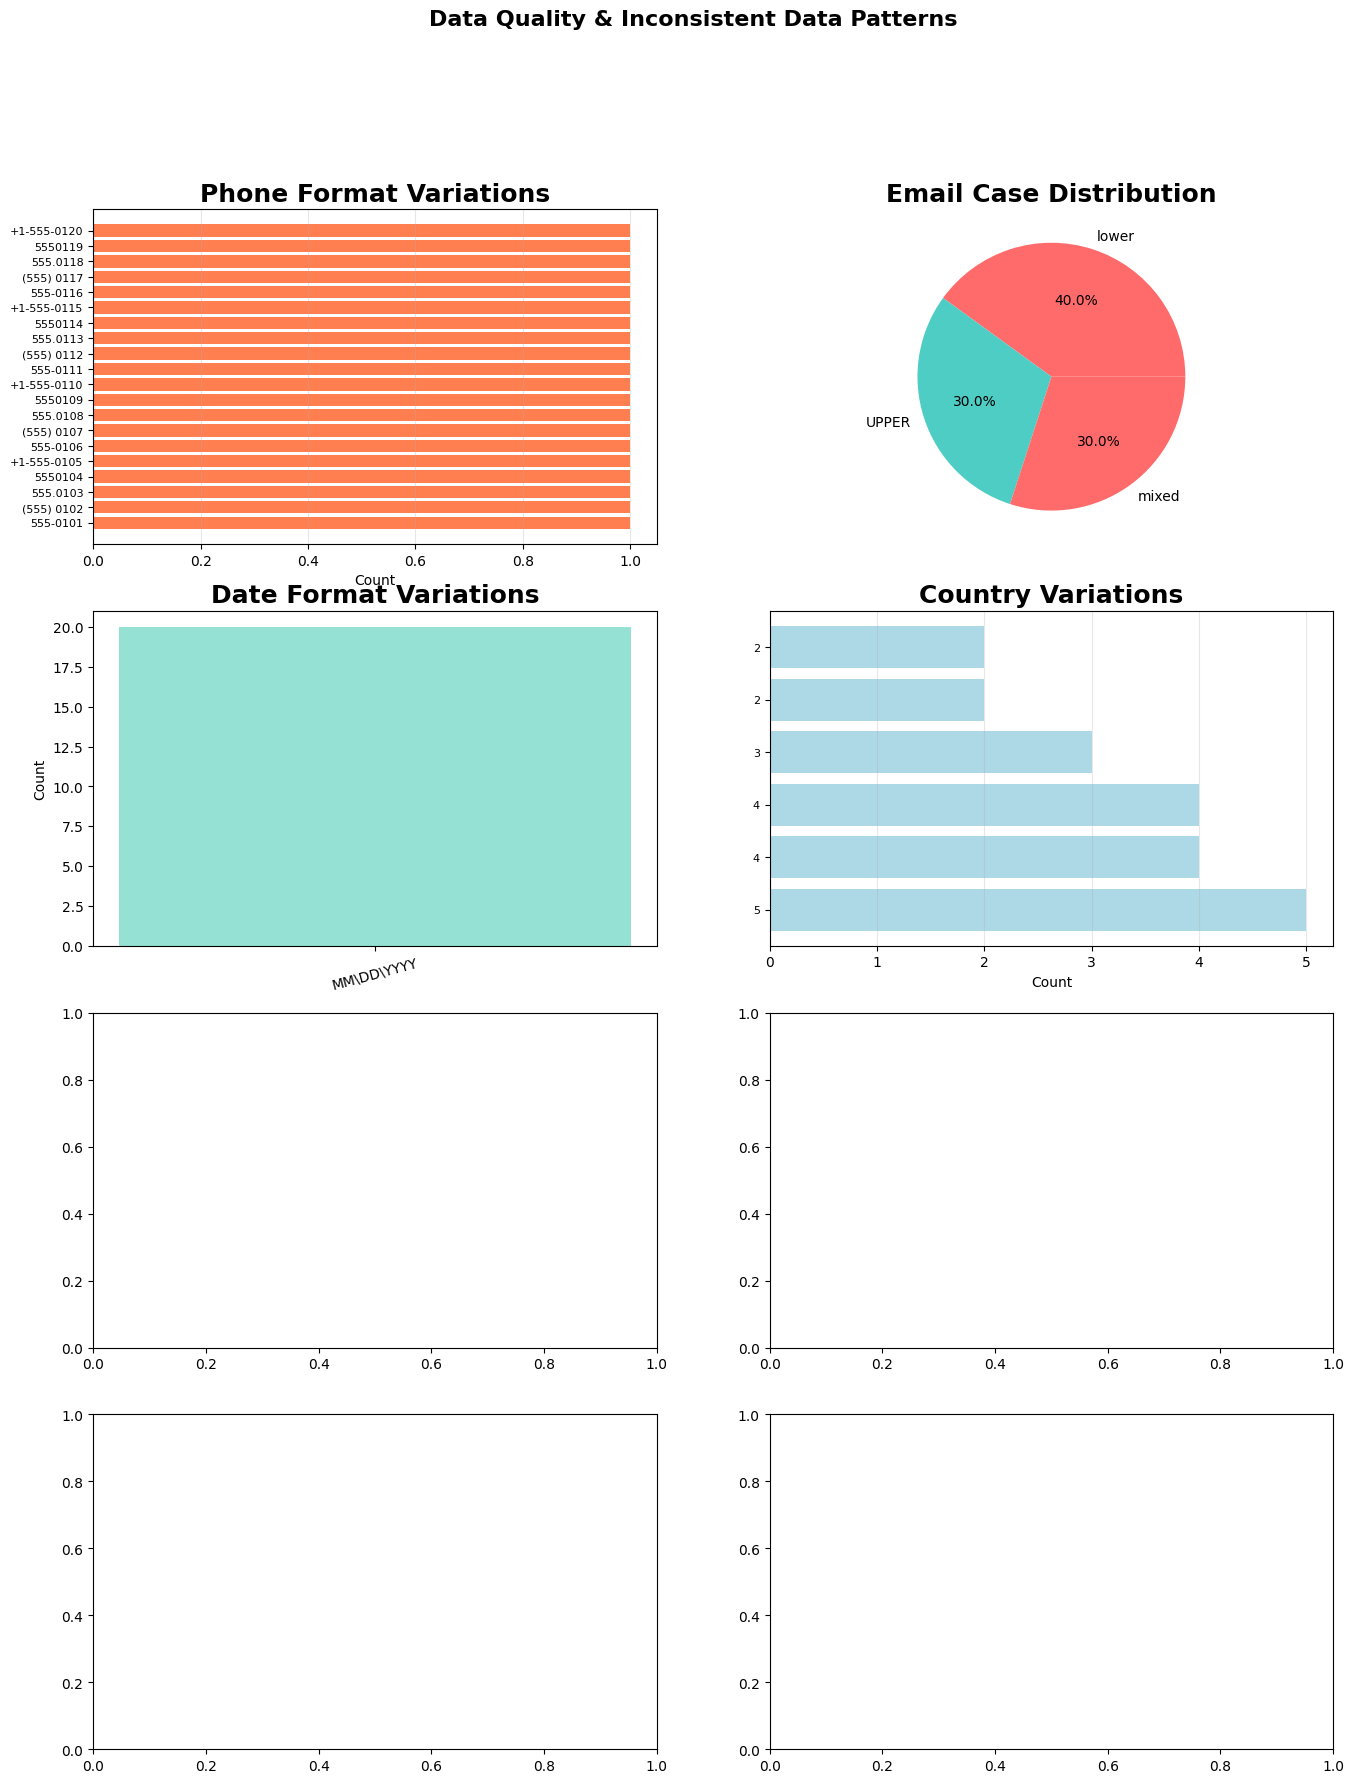

In [36]:
fig, axes = plt.subplots(4,2,figsize=(16,20))
fig.suptitle('Data Quality & Inconsistent Data Patterns',fontsize=16,fontweight='bold')


axes[0,0].barh(range(len(phone_patterns)),
               phone_patterns.values,color='coral')
axes[0,0].set_yticks(range(len(phone_patterns)))
axes[0,0].set_yticklabels(phone_patterns.index,fontsize=8)
axes[0,0].set_xlabel('Count')
axes[0,0].set_title('Phone Format Variations',fontsize=18,fontweight='bold')
axes[0,0].grid(axis='x',alpha=0.3)




colors = ['#FF6B6B','#4ECDC4','#FF6B6B']
axes[0,1].pie(email_patterns.values,labels=email_patterns.index,colors=colors,autopct='%1.1f%%')
axes[0,1].set_title('Email Case Distribution',fontsize=18,fontweight='bold')




axes[1,0].bar(date_patterns.index,date_patterns.values,color=['#95E1D3','#F38181'])
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Date Format Variations',fontsize=18,fontweight='bold')
axes[1,0].tick_params(axis='x',rotation=15)



axes[1,1].barh(range(len(country_counts)),country_counts.values,color='lightblue')
axes[1,1].set_yticks(range(len(country_counts)))
axes[1,1].set_yticklabels(country_counts,fontsize=8)
axes[1,1].set_xlabel('Count')
axes[1,1].set_title('Country Variations',fontsize=18,fontweight='bold')
axes[1,1].grid(axis='x',alpha=0.3)




